In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
data_path = "/mnt/optimus/don226/full_data"
data_ = pd.read_parquet(data_path)

In [3]:
# List of ids (households)
id_list = data_['ID'].unique().tolist()

In [20]:
# Randomly select an id (a household) to plot
while True:
    id = random.choice(id_list) # 8319614

    data = data_[data_["ID"] == id]
    data.sort_values(by="READING_DATETIME", inplace=True)
    data.reset_index(drop=True, inplace=True)
    
    # Check to see if there're any missing values
    if data.isnull().sum().sum() == 0:
        print(f"Chosen id is: {id}")
        break
data.head()

Chosen id is: 8680582


/tmp/ipykernel_497354/3940528187.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by="READING_DATETIME", inplace=True)


,ID,CONSUMPTION,READING_DATETIME,HOUR
0,8680582,0.098,2012-05-08 12:00:00,12
1,8680582,0.230,2012-05-08 12:30:00,12
2,8680582,0.487,2012-05-08 13:00:00,13
3,8680582,0.720,2012-05-08 13:30:00,13
4,8680582,0.640,2012-05-08 14:00:00,14


## Plots

## Plot the energy consumption by half-hour intervals for a random day

In [21]:
# Randomly select a day to plot
min_date = data["READING_DATETIME"].dt.date.min()
max_date = data["READING_DATETIME"].dt.date.max()

while True:
    random_date = min_date + pd.Timedelta(days=random.randint(0, (max_date - min_date).days))

    # selected_date = data[data["READING_DATETIME"].dt.date == random_date.date()]
    selected_date = data[data["READING_DATETIME"].dt.date == random_date]

    # Check if the random date has 48 records (since not all data starts recording at 00:00:00)
    if len(selected_date) == 48:
        print(f"Random date is: {random_date}")
        break

Random date is: 2013-10-29


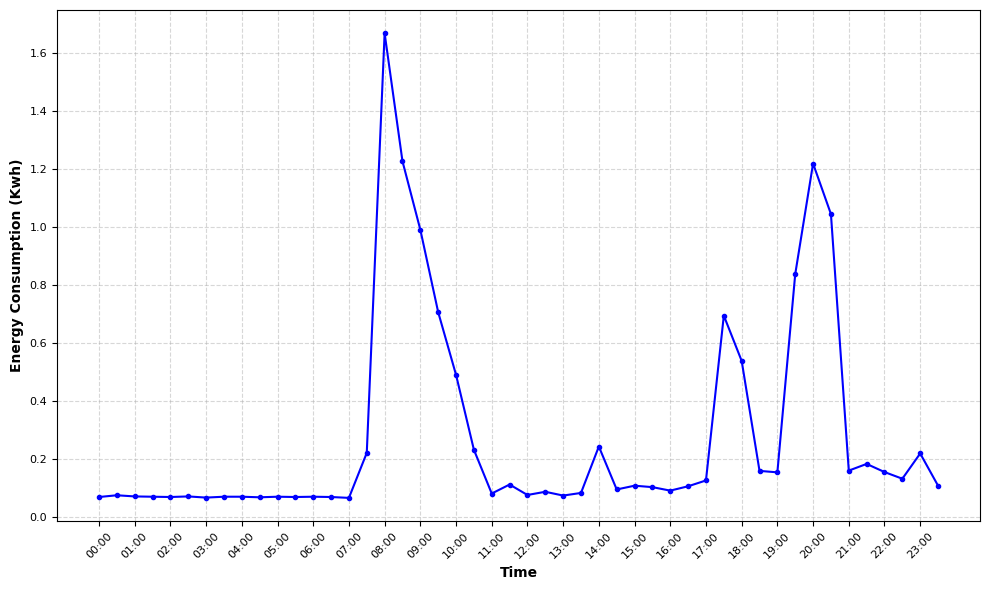

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(selected_date["READING_DATETIME"], selected_date["CONSUMPTION"], color='blue', linestyle='-', marker='o', markersize=3)

plt.xlabel('Time', fontsize=10, fontweight='bold')
plt.ylabel('Energy Consumption (Kwh)', fontsize=10, fontweight='bold')
# plt.title(f'Date: {random_date}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=8)
plt.gca().set_xticks(selected_date["READING_DATETIME"][::2])
plt.gca().set_xticklabels(selected_date["READING_DATETIME"][::2].dt.strftime('%H:%M'), fontsize=8)
plt.yticks(fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## Plot the energy consumption by hourly intervals for a random day

In [ ]:
# Add hours column
selected_date["HOUR"] = selected_date['READING_DATETIME'].dt.hour

# Calculate the mean consumption for each hour
mean_per_hr_1d = selected_date.groupby(['HOUR'])['CONSUMPTION'].mean().reset_index()

/tmp/ipykernel_497354/2184557111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_date["HOUR"] = selected_date['READING_DATETIME'].dt.hour


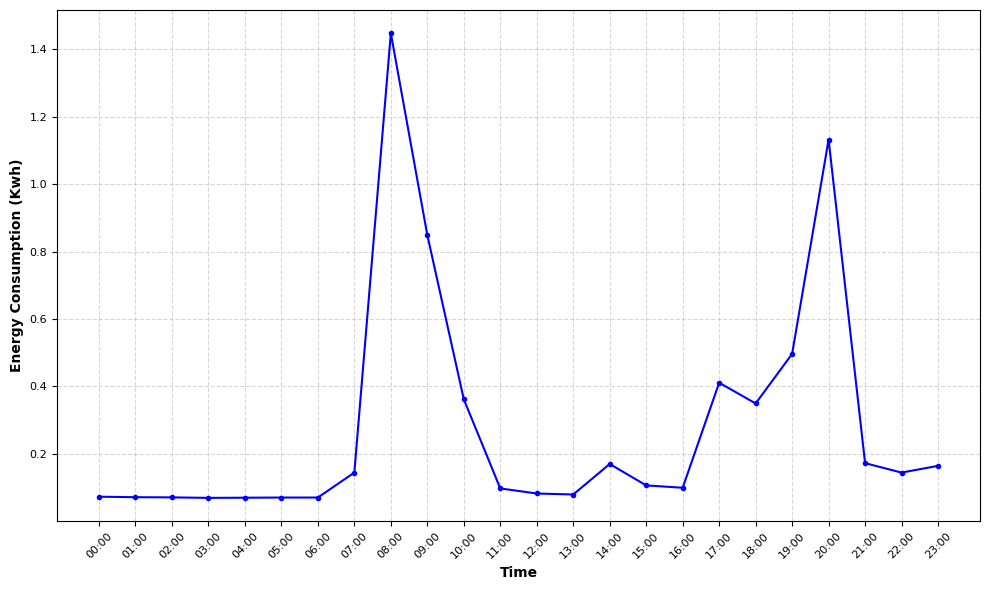

In [24]:


plt.figure(figsize=(10, 6))
plt.plot(
    mean_per_hr_1d["HOUR"],
    mean_per_hr_1d['CONSUMPTION'],
    color='blue', 
    linestyle='-', 
    marker='o', 
    markersize=3)

plt.xlabel('Time', fontsize=10, fontweight='bold')
plt.ylabel('Energy Consumption (Kwh)', fontsize=10, fontweight='bold')
plt.xticks(rotation=45, fontsize=8)
plt.xticks(mean_per_hr_1d["HOUR"], [f"{hour:02d}:00" for hour in mean_per_hr_1d["HOUR"]])
plt.yticks(fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Plot the energy consumption by hourly intervals for the entire recording period of the selected household.

#### Aggregate by mean

In [25]:
# Add hours column
data_["HOUR"] = data_['READING_DATETIME'].dt.hour

mean_per_hr = data_.groupby(['HOUR'])['CONSUMPTION'].mean().reset_index().sort_values(by=["HOUR"]).reset_index(drop=True)


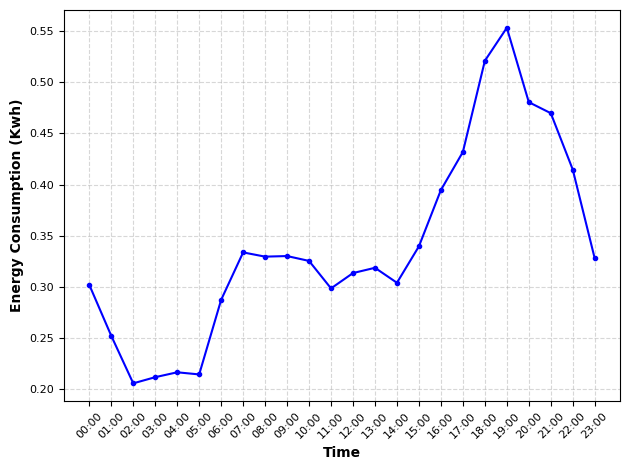

In [26]:
plt.plot(
    mean_per_hr["HOUR"],
    mean_per_hr['CONSUMPTION'],
    color='blue', 
    linestyle='-', 
    marker='o', 
    markersize=3)

plt.xlabel('Time', fontsize=10, fontweight='bold')
plt.ylabel('Energy Consumption (Kwh)', fontsize=10, fontweight='bold')
plt.xticks(rotation=45, fontsize=8)
plt.xticks(mean_per_hr["HOUR"], [f"{hour:02d}:00" for hour in mean_per_hr["HOUR"]])
plt.yticks(fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

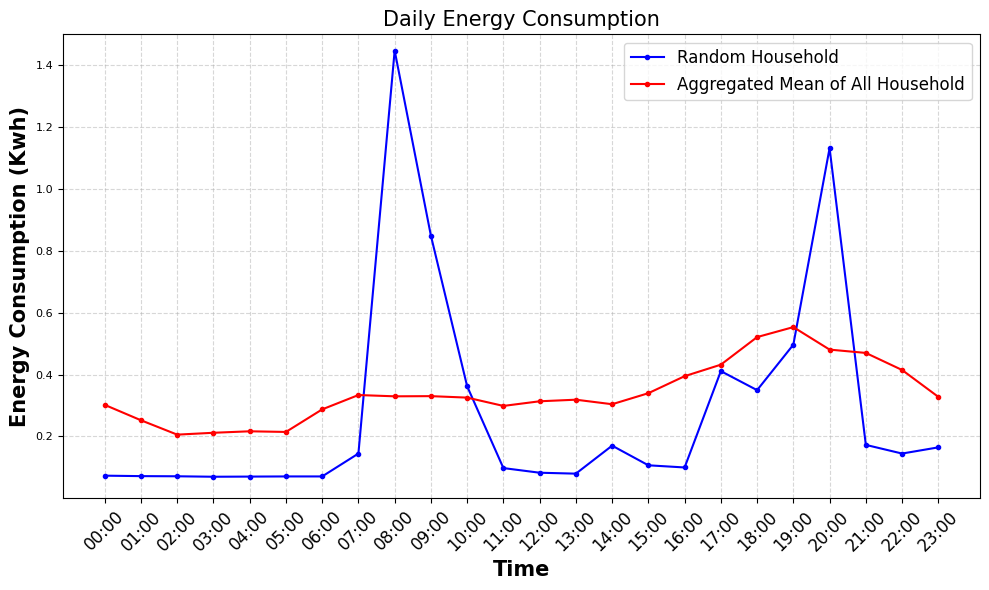

In [32]:
# Create a figure with one subplot
fig, ax = plt.subplots(figsize=(10, 6))  # 1 row, 1 column

# Plot for the first dataset
ax.plot(
    mean_per_hr_1d["HOUR"],
    mean_per_hr_1d['CONSUMPTION'],
    color='blue',
    linestyle='-',
    marker='o',
    markersize=3,
    label='Random Household')

# Plot for the second dataset, superimposed on the same axes
ax.plot(
    mean_per_hr["HOUR"],
    mean_per_hr['CONSUMPTION'],
    color='red',  # You can choose a different color
    linestyle='-',
    marker='o',
    markersize=3,
    label='Aggregated Mean of All Household')

ax.set_xlabel('Time', fontsize=15, fontweight='bold')
ax.set_ylabel('Energy Consumption (Kwh)', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.set_xticks(mean_per_hr_1d["HOUR"])
ax.set_xticklabels([f"{hour:02d}:00" for hour in mean_per_hr_1d["HOUR"]], fontsize=12)
ax.tick_params(axis='y', labelsize=8)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Daily Energy Consumption', fontsize=15)  # Add a title if needed
ax.set_ylim(top=1.5)  # Set upper bound for y-axis

# Add legend
ax.legend(fontsize=12)

# Adjust layout
plt.tight_layout()

# Save the plot into a PDF file
plt.savefig('output_superimposed_plot.pdf')

# Show the plot
plt.show()

#### Aggregate by Median

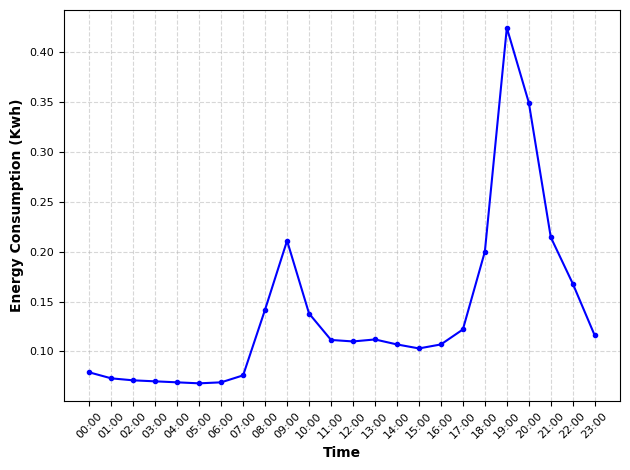

In [27]:
median_per_hr = data.groupby(['HOUR'])['CONSUMPTION'].median().reset_index().sort_values(by=["HOUR"]).reset_index(drop=True)
plt.plot(
    median_per_hr["HOUR"],
    median_per_hr['CONSUMPTION'],
    color='blue', 
    linestyle='-', 
    marker='o', 
    markersize=3)

plt.xlabel('Time', fontsize=10, fontweight='bold')
plt.ylabel('Energy Consumption (Kwh)', fontsize=10, fontweight='bold')
plt.xticks(rotation=45, fontsize=8)
plt.xticks(median_per_hr["HOUR"], [f"{hour:02d}:00" for hour in median_per_hr["HOUR"]])
plt.yticks(fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()